### 1) Problem statement
- This project understands how the student's performance (test scores) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course.

In [73]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

warnings.filterwarnings('ignore')


In [74]:
df=pd.read_csv('data/stud.csv')

In [75]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [76]:
df.shape

(1000, 8)

In [77]:
len(df.columns)

8

In [78]:
print(df.columns)

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='object')


### 3. Data Checks to perform

- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of data set
- Check various categories present in the different categorical column

In [79]:
df.isnull().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [80]:
df.duplicated().sum()

0

In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [82]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [83]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [84]:
print("categories in Gender variables",df['gender'].unique())
print("categories in Race/Ethnicity variables",df['race_ethnicity'].unique())
print("categories in Parental Level of Education variables",df['parental_level_of_education'].unique())
print("categories in Lunch variables",df['lunch'].unique())
print("categories in Test preparation course variables",df['test_preparation_course'].unique())


categories in Gender variables ['female' 'male']
categories in Race/Ethnicity variables ['group B' 'group C' 'group A' 'group D' 'group E']
categories in Parental Level of Education variables ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
categories in Lunch variables ['standard' 'free/reduced']
categories in Test preparation course variables ['none' 'completed']


In [85]:
numeric_feature=df.select_dtypes(include=['number']).dtypes
category_feature=df.select_dtypes(include=['object','category']).dtypes
print(numeric_feature)

math_score       int64
reading_score    int64
writing_score    int64
dtype: object


In [86]:
print(category_feature)

gender                         object
race_ethnicity                 object
parental_level_of_education    object
lunch                          object
test_preparation_course        object
dtype: object


### 3.8 Adding columns for "Total Score" and "Average"

In [87]:
df['total score']=df['math_score']+df['reading_score']+df['writing_score']
df['average']=df['total score']/3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [88]:
reading_full=df[df['reading_score']==100]['average'].count()
print("number of students getting full marks in reading",reading_full)

number of students getting full marks in reading 17


In [89]:
math_full=df[df['math_score']==100]['average'].count()
print("number of students getting full marks in maths",math_full)

number of students getting full marks in maths 7


In [90]:
writing_full=df[df['writing_score']==100]['average'].count()
print("number of students getting full marks in writing",writing_full)

number of students getting full marks in writing 14


### 4. Exploring Data ( Visualization )
- Histogram
- Kernel Distribution Function (KDE)

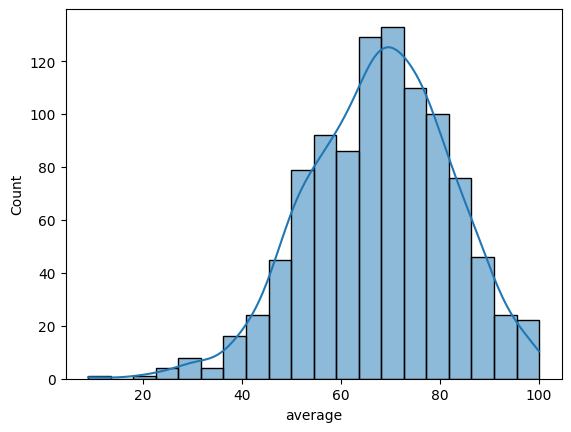

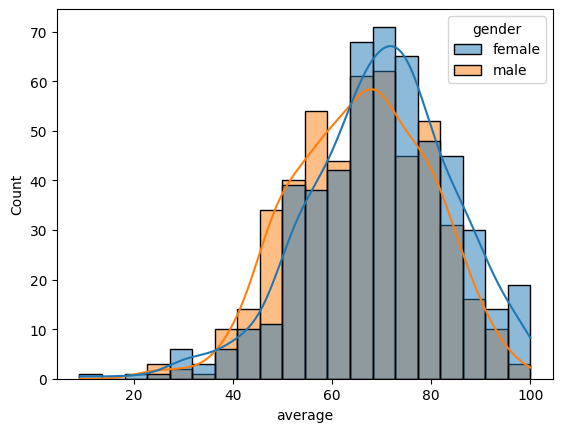

In [91]:
# Univariate analysis for Numerical features
sns.histplot(data=df,x='average',bins=20,kde=True)
plt.show()
sns.histplot(data=df,x='average',bins=20,kde=True,hue='gender')
plt.show()

# bins= values is divided into 20 equal intervals (bars).

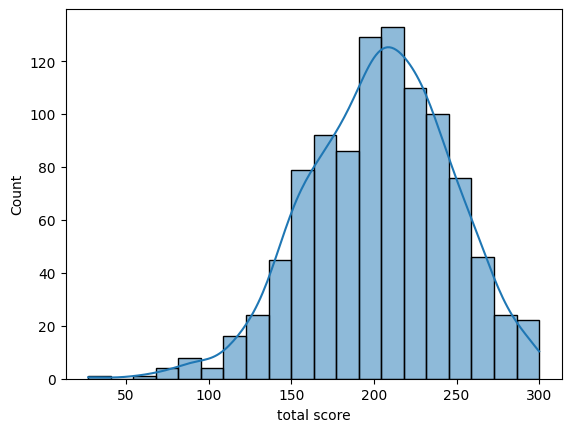

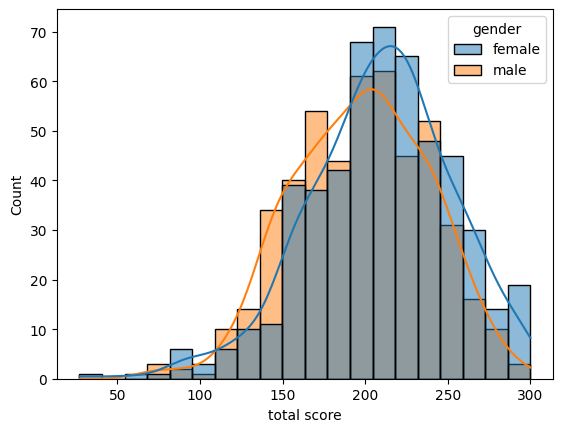

In [92]:
sns.histplot(data=df,x='total score',bins=20,kde=True)
plt.show()
sns.histplot(data=df,x='total score',bins=20,kde=True,hue='gender')
plt.show()

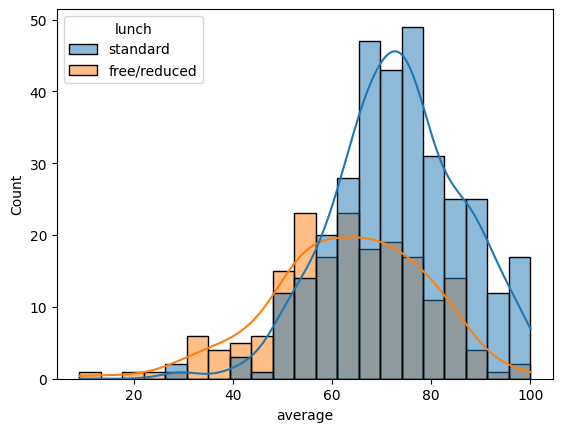

In [93]:
sns.histplot(data=df[df.gender=='female'],x='average',kde=True,hue='lunch')
plt.show()

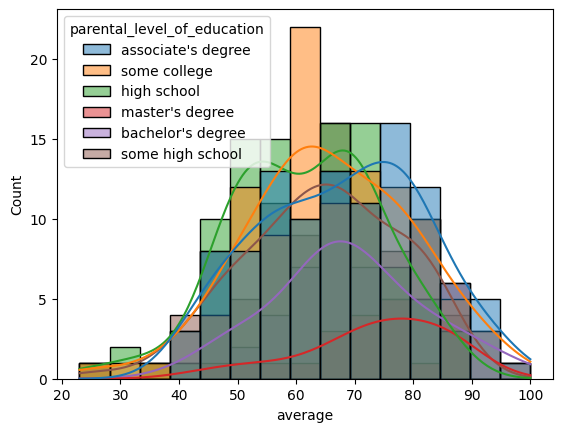

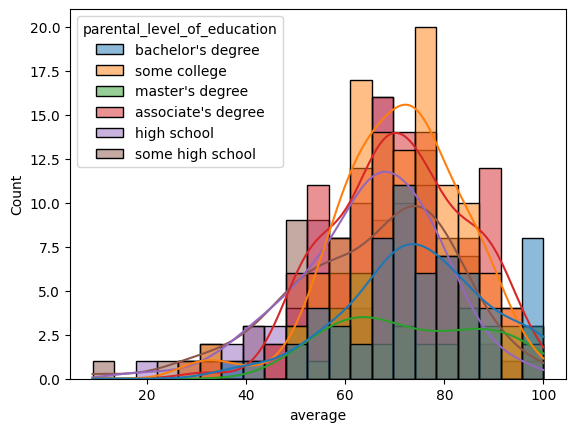

In [94]:
sns.histplot(data=df[df.gender=='male'],x='average',kde=True,hue='parental_level_of_education')
plt.show()
sns.histplot(data=df[df.gender=='female'],x='average',kde=True,hue='parental_level_of_education')
plt.show()


<Axes: ylabel='average'>

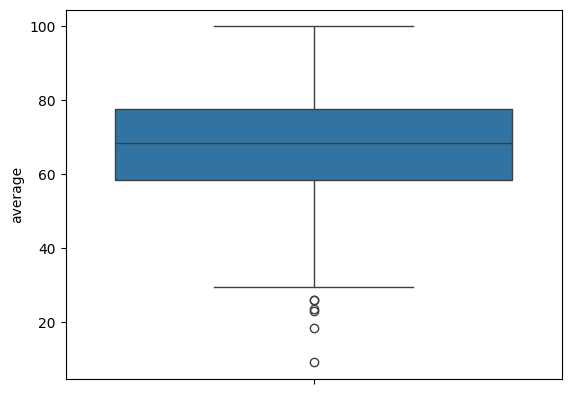

In [95]:
sns.boxplot(data=df, y='average')

<Axes: ylabel='total score'>

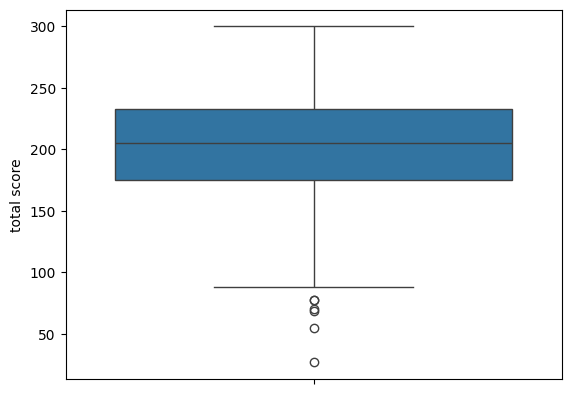

In [96]:
sns.boxplot(data=df, y='total score')

# Bivariate analysis for Numerical features
(a) Numeric vs Numeric

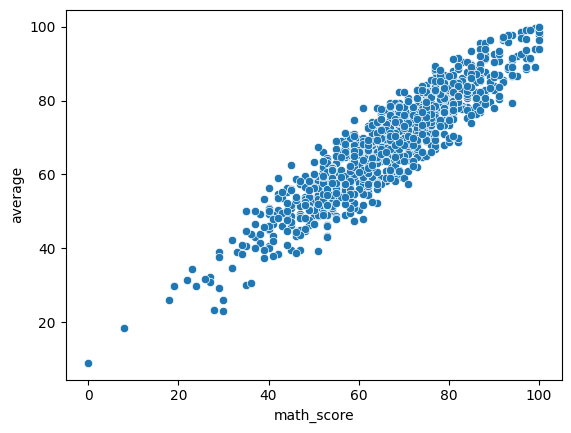

In [97]:
sns.scatterplot(data=df, x='math_score', y='average')
plt.show()


<Axes: xlabel='reading_score', ylabel='average'>

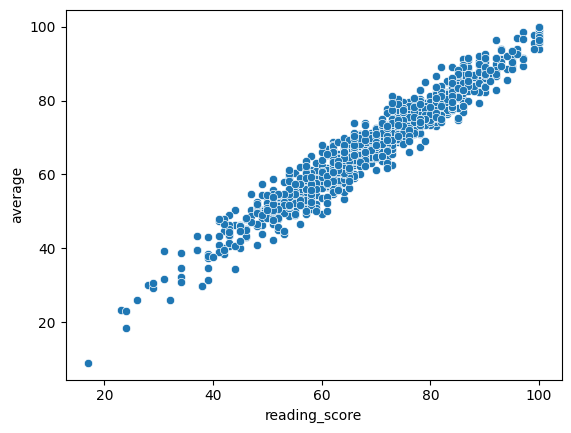

In [98]:
sns.scatterplot(data=df,x='reading_score',y='average')

(b) Categorical vs Numeric

<Axes: xlabel='gender', ylabel='average'>

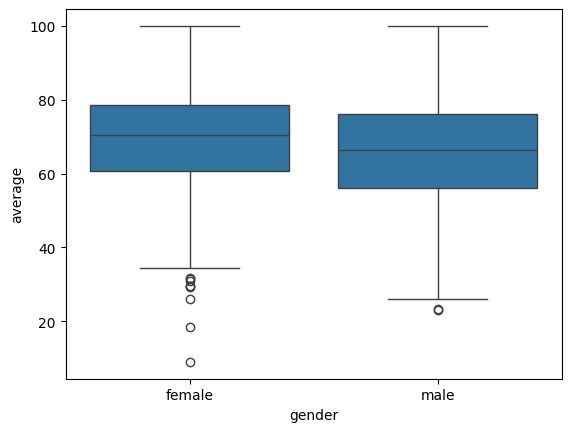

In [99]:
sns.boxplot(data=df,x='gender',y='average')

<Axes: xlabel='gender', ylabel='count'>

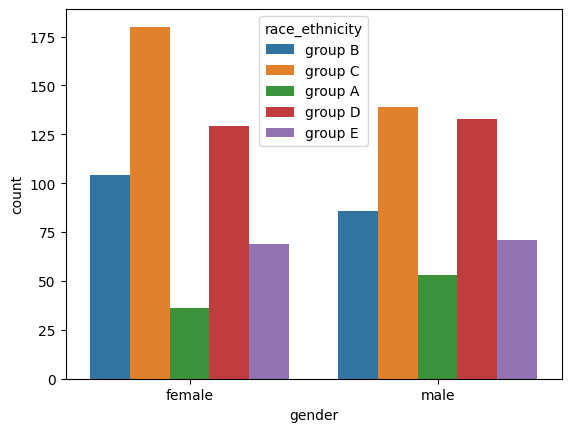

In [100]:
sns.countplot(data=df,x='gender',hue='race_ethnicity')

# #Multivariate in EDA

In [101]:
df.corr(numeric_only=True)

,math_score,reading_score,writing_score,total score,average
math_score,1.000000,0.817580,0.802642,0.918746,0.918746
reading_score,0.817580,1.000000,0.954598,0.970331,0.970331
writing_score,0.802642,0.954598,1.000000,0.965667,0.965667
total score,0.918746,0.970331,0.965667,1.000000,1.000000
average,0.918746,0.970331,0.965667,1.000000,1.000000


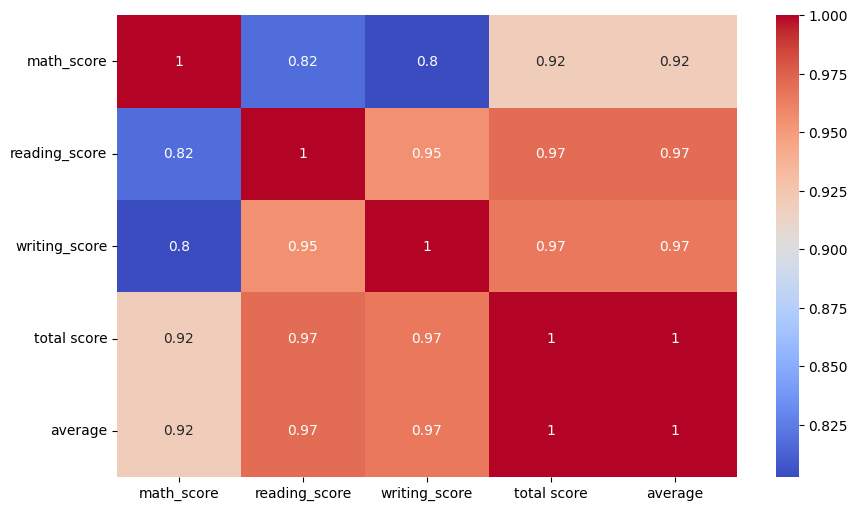

In [102]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.show()

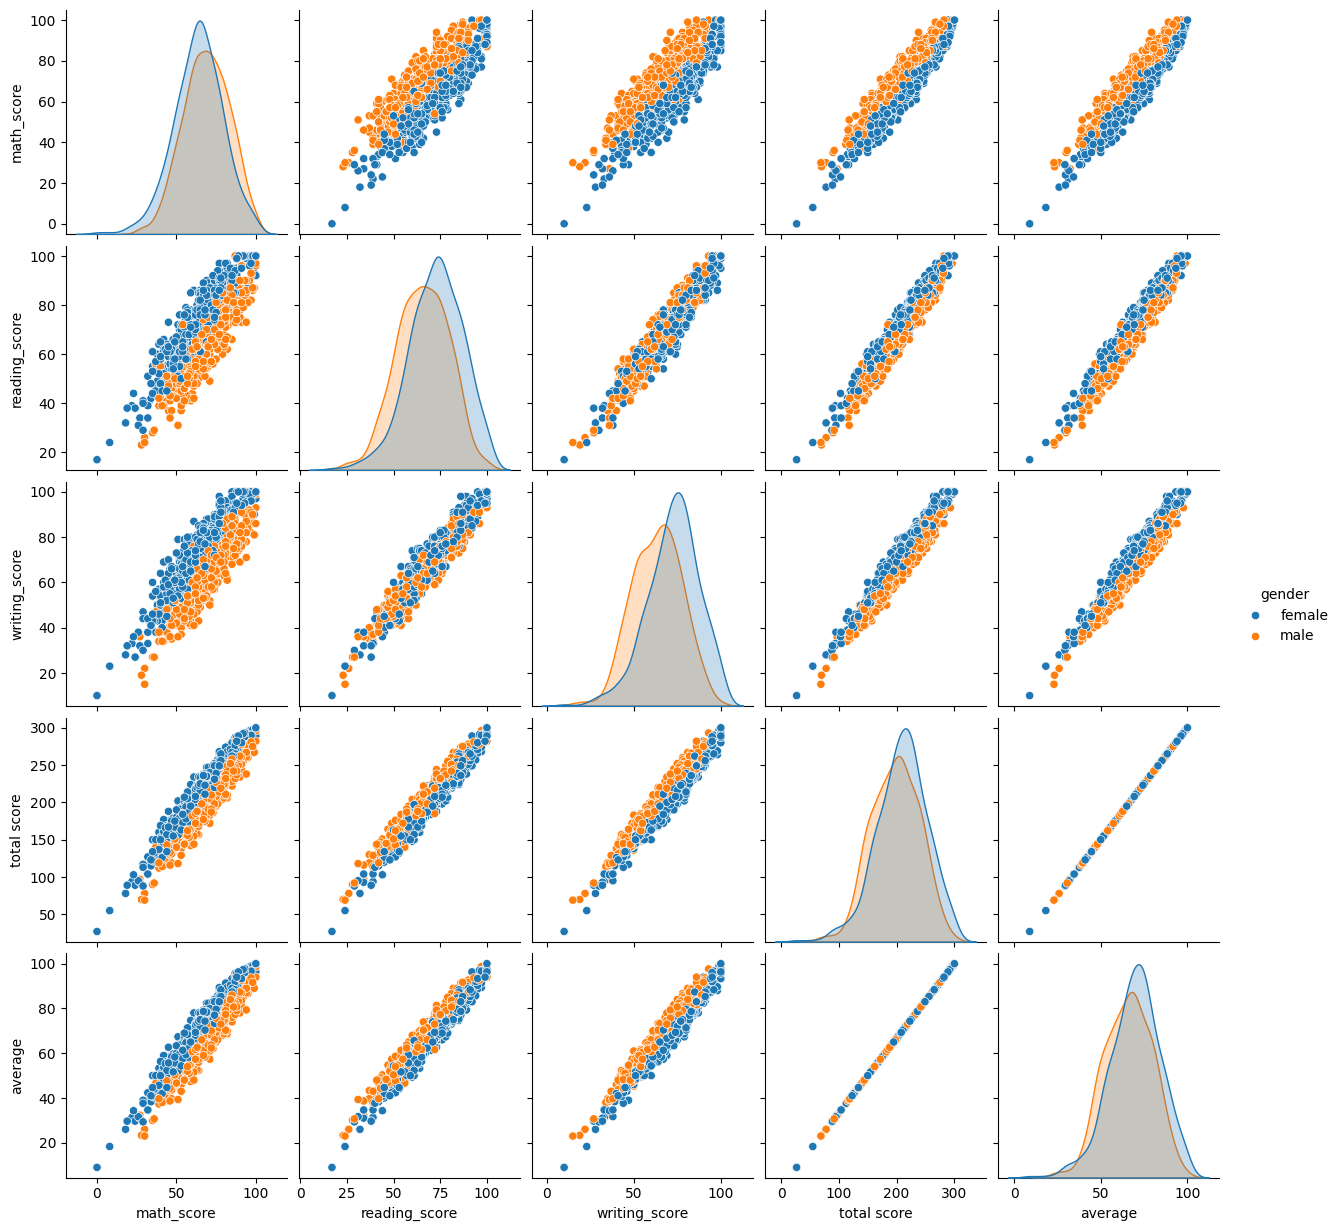

In [103]:
sns.pairplot(df,hue='gender')